##Data 1


In [ ]:
import torch
print("GPU available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

!pip install segmentation-models-pytorch -q


GPU available: True
Device: Tesla T4


In [ ]:

from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/water_segmentation', exist_ok=True)
print("Drive mounted. Results saved to: /content/drive/MyDrive/water_segmentation/")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Results saved to: /content/drive/MyDrive/water_segmentation/


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random
from tqdm import tqdm
import os

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms.functional as TF
import segmentation_models_pytorch as smp

IMAGE_DIR = '/content/drive/MyDrive/Water_Bodies_Dataset/Images'
MASK_DIR = '/content/drive/MyDrive/Water_Bodies_Dataset/Masks'
SAVE_DIR = '/content/drive/MyDrive/water_segmentation'

print(f"Images found: {len(os.listdir(IMAGE_DIR))}")
print(f"Masks found: {len(os.listdir(MASK_DIR))}")


Images found: 2841
Masks found: 2841


In [ ]:
image_files = sorted(os.listdir(IMAGE_DIR))
mask_files = sorted(os.listdir(MASK_DIR))

print(f"Total image-mask pairs: {len(image_files)}")
print(f"Images: {len(image_files)}, Masks: {len(mask_files)}")
print(f"Counts match: {len(image_files) == len(mask_files)}")
print(f"Sample image: {image_files[6]}")
print(f"Sample mask: {mask_files[6]}")


Total image-mask pairs: 2841
Images: 2841, Masks: 2841
Counts match: True
Sample image: water_body_1004.jpg
Sample mask: water_body_1004.jpg


In [ ]:
zero_water_count = 0
total_masks = len(mask_files)

print("Checking mask quality...")
for mask_file in tqdm(mask_files):
    mask = Image.open(os.path.join(MASK_DIR, mask_file)).convert('L')
    mask_array = np.array(mask)
    if mask_array.max() == 0:
        zero_water_count += 1

print(f"\\nTotal masks: {total_masks}")
print(f"Fully black masks (no water): {zero_water_count}")
print(f"Percentage: {100 * zero_water_count / total_masks:.2f}%")


Checking mask quality...


100%|██████████| 2841/2841 [01:38<00:00, 28.74it/s] 

\nTotal masks: 2841
Fully black masks (no water): 0
Percentage: 0.00%


Computing water ratios...


100%|██████████| 2841/2841 [00:18<00:00, 156.71it/s]


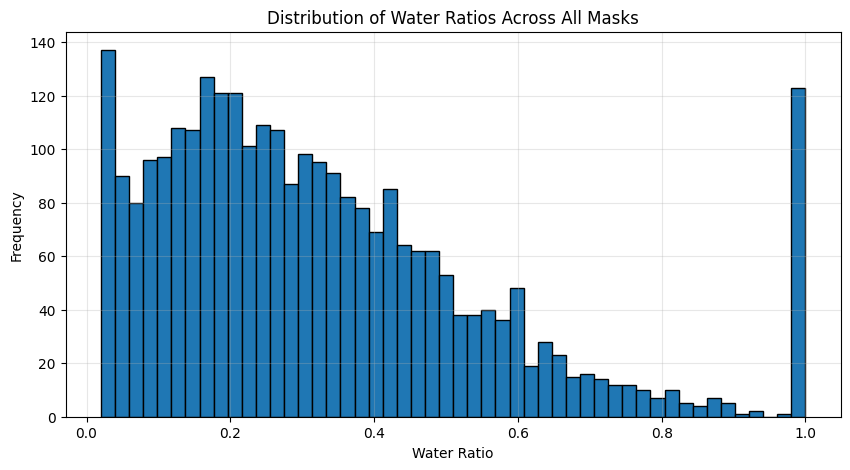


Mean water ratio: 0.3289
Min water ratio: 0.0200
Max water ratio: 1.0000


In [ ]:
water_ratios = []

print("Computing water ratios...")
for mask_file in tqdm(mask_files):
    mask = Image.open(os.path.join(MASK_DIR, mask_file)).convert('L')
    mask_array = np.array(mask)
    white_pixels = (mask_array > 127).sum()
    total_pixels = mask_array.size
    water_ratio = white_pixels / total_pixels
    water_ratios.append(water_ratio)

water_ratios = np.array(water_ratios)

plt.figure(figsize=(10, 5))
plt.hist(water_ratios, bins=50, edgecolor='black')
plt.xlabel('Water Ratio')
plt.ylabel('Frequency')
plt.title('Distribution of Water Ratios Across All Masks')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nMean water ratio: {water_ratios.mean():.4f}")
print(f"Min water ratio: {water_ratios.min():.4f}")
print(f"Max water ratio: {water_ratios.max():.4f}")


In [ ]:
class WaterBodyDataset(Dataset):
    def __init__(self, image_dir, mask_dir, img_size=256, augment=False):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.img_size = img_size
        self.augment = augment
        self.images = sorted(os.listdir(image_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        fname = self.images[idx]
        image = Image.open(os.path.join(self.image_dir, fname)).convert('RGB')
        mask = Image.open(os.path.join(self.mask_dir, fname)).convert('L')

        # Resize
        image = image.resize((self.img_size, self.img_size), Image.BILINEAR)
        mask = mask.resize((self.img_size, self.img_size), Image.NEAREST)

        # Augmentation
        if self.augment:
            image, mask = self._augment(image, mask)

        # Image to tensor and normalize
        image = TF.to_tensor(image)
        image = TF.normalize(image, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

        # Mask to binary tensor [1, H, W]
        mask = np.array(mask, dtype=np.float32)
        mask = (mask > 127).astype(np.float32)
        mask = torch.from_numpy(mask).unsqueeze(0)

        return image, mask

    def _augment(self, image, mask):
        if random.random() > 0.5:
            image, mask = TF.hflip(image), TF.hflip(mask)
        if random.random() > 0.5:
            image, mask = TF.vflip(image), TF.vflip(mask)
        angle = random.choice([0, 90, 180, 270])
        image, mask = TF.rotate(image, angle), TF.rotate(mask, angle)
        if random.random() > 0.5:
            image = TF.adjust_brightness(image, random.uniform(0.8, 1.2))
            image = TF.adjust_contrast(image, random.uniform(0.8, 1.2))
        return image, mask

print("Dataset class defined!")



Dataset class defined!


In [ ]:

BATCH_SIZE = 8
IMG_SIZE = 256

full_ds = WaterBodyDataset(IMAGE_DIR, MASK_DIR, img_size=IMG_SIZE, augment=False)

n = len(full_ds)
n_train = int(0.70 * n)
n_val = int(0.15 * n)
n_test = n - n_train - n_val

train_ds, val_ds, test_ds = random_split(
    full_ds, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

# Enable augmentation for training only
train_ds.dataset.augment = True

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")



Train: 1988 | Val: 426 | Test: 427


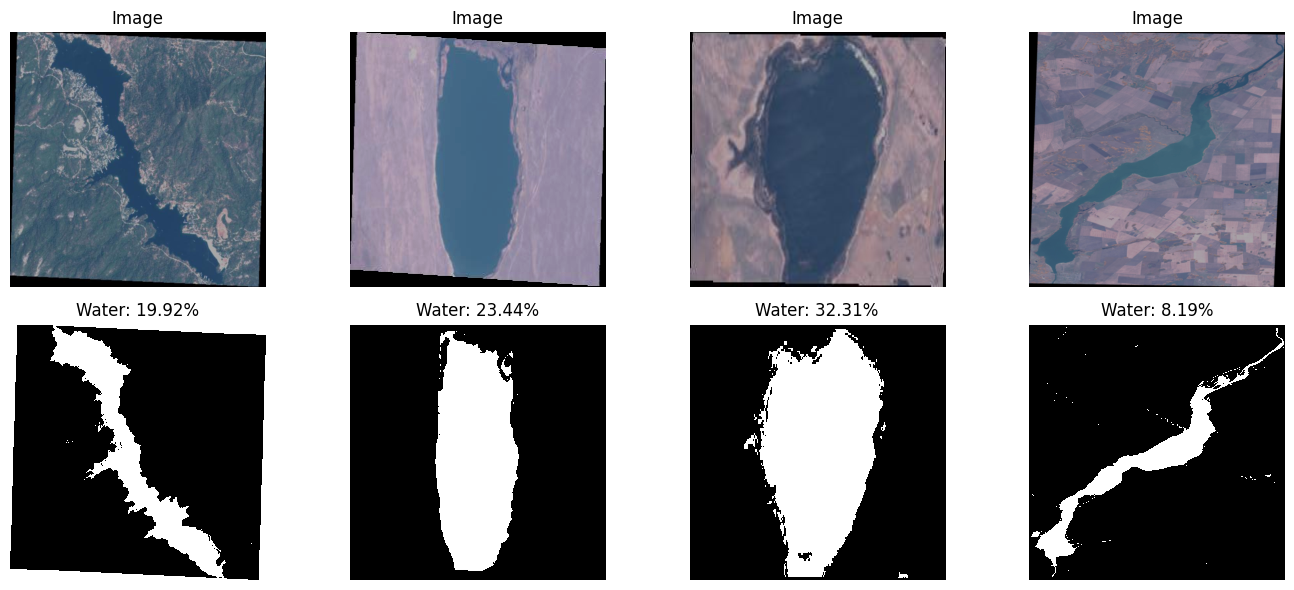

In [ ]:
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

imgs, masks = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for i in range(4):
    img_disp = (imgs[i] * STD + MEAN).permute(1, 2, 0).clamp(0, 1).numpy()
    msk_disp = masks[i, 0].numpy()
    axes[0, i].imshow(img_disp)
    axes[0, i].set_title("Image")
    axes[0, i].axis("off")
    axes[1, i].imshow(msk_disp, cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title(f"Water: {msk_disp.mean():.2%}")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()


In [ ]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)
model = model.to(device)

print(f"Model loaded on {device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Model loaded on cuda
Total parameters: 24,436,369


In [ ]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs = probs.view(-1)
        targets = targets.view(-1)
        intersection = (probs * targets).sum()
        dice = (2.0 * intersection + self.smooth) / (probs.sum() + targets.sum() + self.smooth)
        return 1 - dice

class BCEDiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super(BCEDiceLoss, self).__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss(smooth=smooth)

    def forward(self, logits, targets):
        return 0.5 * self.bce(logits, targets) + 0.5 * self.dice(logits, targets)

criterion = BCEDiceLoss(smooth=1.0)
print("Loss function: BCEDiceLoss (0.5 * BCE + 0.5 * Dice)")


Loss function: BCEDiceLoss (0.5 * BCE + 0.5 * Dice)


In [ ]:
def iou_score(logits, targets, threshold=0.5, epsilon=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    targets = targets.float()

    intersection = (preds * targets).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3)) - intersection
    iou = (intersection + epsilon) / (union + epsilon)
    return iou.mean().item()

def dice_score(logits, targets, threshold=0.5, epsilon=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    targets = targets.float()

    intersection = (preds * targets).sum(dim=(1, 2, 3))
    dice = (2.0 * intersection + epsilon) / (preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3)) + epsilon)
    return dice.mean().item()

print("Metrics defined: IoU and Dice")



Metrics defined: IoU and Dice


In [ ]:

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

EPOCHS = 30
best_val_loss = float('inf')

history = {
    'train_loss': [],
    'val_loss': [],
    'val_iou': [],
    'val_dice': []
}

print("Training setup complete!")
print(f"Optimizer: Adam (lr=1e-4)")
print(f"Scheduler: ReduceLROnPlateau (patience=5, factor=0.5)")
print(f"Epochs: {EPOCHS}")



Training setup complete!
Optimizer: Adam (lr=1e-4)
Scheduler: ReduceLROnPlateau (patience=5, factor=0.5)
Epochs: 30


In [ ]:
for epoch in range(EPOCHS):
    # Training
    model.train()
    train_loss = 0.0

    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0
    val_iou = 0.0
    val_dice = 0.0

    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
            images, masks = images.to(device), masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            val_loss += loss.item()
            val_iou += iou_score(outputs, masks)
            val_dice += dice_score(outputs, masks)

    val_loss /= len(val_loader)
    val_iou /= len(val_loader)
    val_dice /= len(val_loader)

    # Update scheduler
    scheduler.step(val_loss)

    # Save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_iou'].append(val_iou)
    history['val_dice'].append(val_dice)

    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val IoU: {val_iou:.4f} | Val Dice: {val_dice:.4f}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, 'best_model.pth'))
        print(f"  → Best model saved! (Val Loss: {val_loss:.4f})")

print("\\nTraining complete!")



Epoch 1/30 [Val]: 100%|██████████| 54/54 [00:12<00:00,  4.16it/s]


Epoch 1/30 - Train Loss: 0.4063 | Val Loss: 0.3228 | Val IoU: 0.6573 | Val Dice: 0.7653
  → Best model saved! (Val Loss: 0.3228)


Epoch 2/30 [Val]: 100%|██████████| 54/54 [00:08<00:00,  6.12it/s]


Epoch 2/30 - Train Loss: 0.2963 | Val Loss: 0.2849 | Val IoU: 0.6761 | Val Dice: 0.7817
  → Best model saved! (Val Loss: 0.2849)


Epoch 3/30 [Val]: 100%|██████████| 54/54 [00:10<00:00,  5.36it/s]


...

Epoch 28/30 - Train Loss: 0.1389 | Val Loss: 0.1756 | Val IoU: 0.7825 | Val Dice: 0.8541
  → Best model saved! (Val Loss: 0.1756)


Epoch 29/30 [Val]: 100%|██████████| 54/54 [00:09<00:00,  5.67it/s]


Epoch 29/30 - Train Loss: 0.1387 | Val Loss: 0.1720 | Val IoU: 0.7889 | Val Dice: 0.8589
  → Best model saved! (Val Loss: 0.1720)


Epoch 30/30 [Val]: 100%|██████████| 54/54 [00:08<00:00,  6.56it/s]


Epoch 30/30 - Train Loss: 0.1346 | Val Loss: 0.1681 | Val IoU: 0.7948 | Val Dice: 0.8632
  → Best model saved! (Val Loss: 0.1681)
\nTraining complete!


In [ ]:
# Load best model
model.load_state_dict(torch.load(os.path.join(SAVE_DIR, 'best_model.pth')))
model.eval()

test_iou = 0.0
test_dice = 0.0

print("Evaluating on test set...")
with torch.no_grad():
    for images, masks in tqdm(test_loader):
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)

        test_iou += iou_score(outputs, masks)
        test_dice += dice_score(outputs, masks)

test_iou /= len(test_loader)
test_dice /= len(test_loader)

print(f"\\nTest Results:")
print(f"Test IoU: {test_iou:.4f}")
print(f"Test Dice: {test_dice:.4f}")



Evaluating on test set...


100%|██████████| 427/427 [00:19<00:00, 22.07it/s]

\nTest Results:
Test IoU: 0.8012
Test Dice: 0.8690


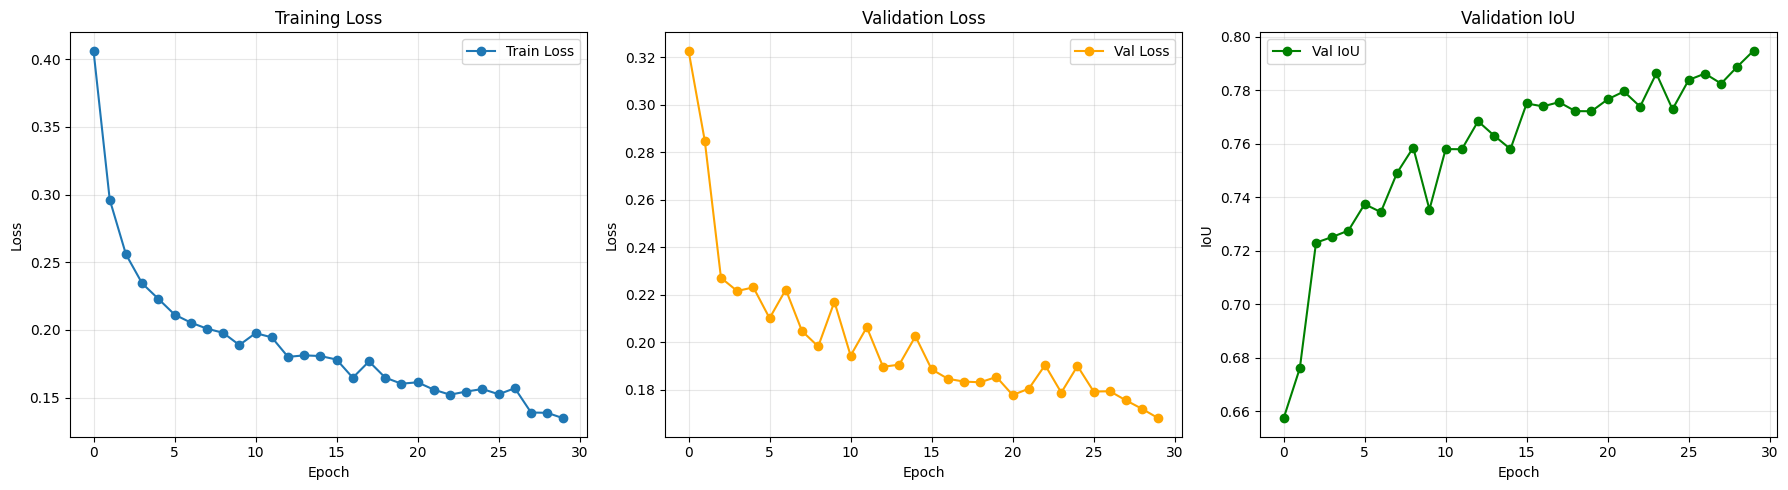

Training curves saved!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Train Loss
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Val Loss
axes[1].plot(history['val_loss'], label='Val Loss', marker='o', color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Validation Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Val IoU
axes[2].plot(history['val_iou'], label='Val IoU', marker='o', color='green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('IoU')
axes[2].set_title('Validation IoU')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Training curves saved!")


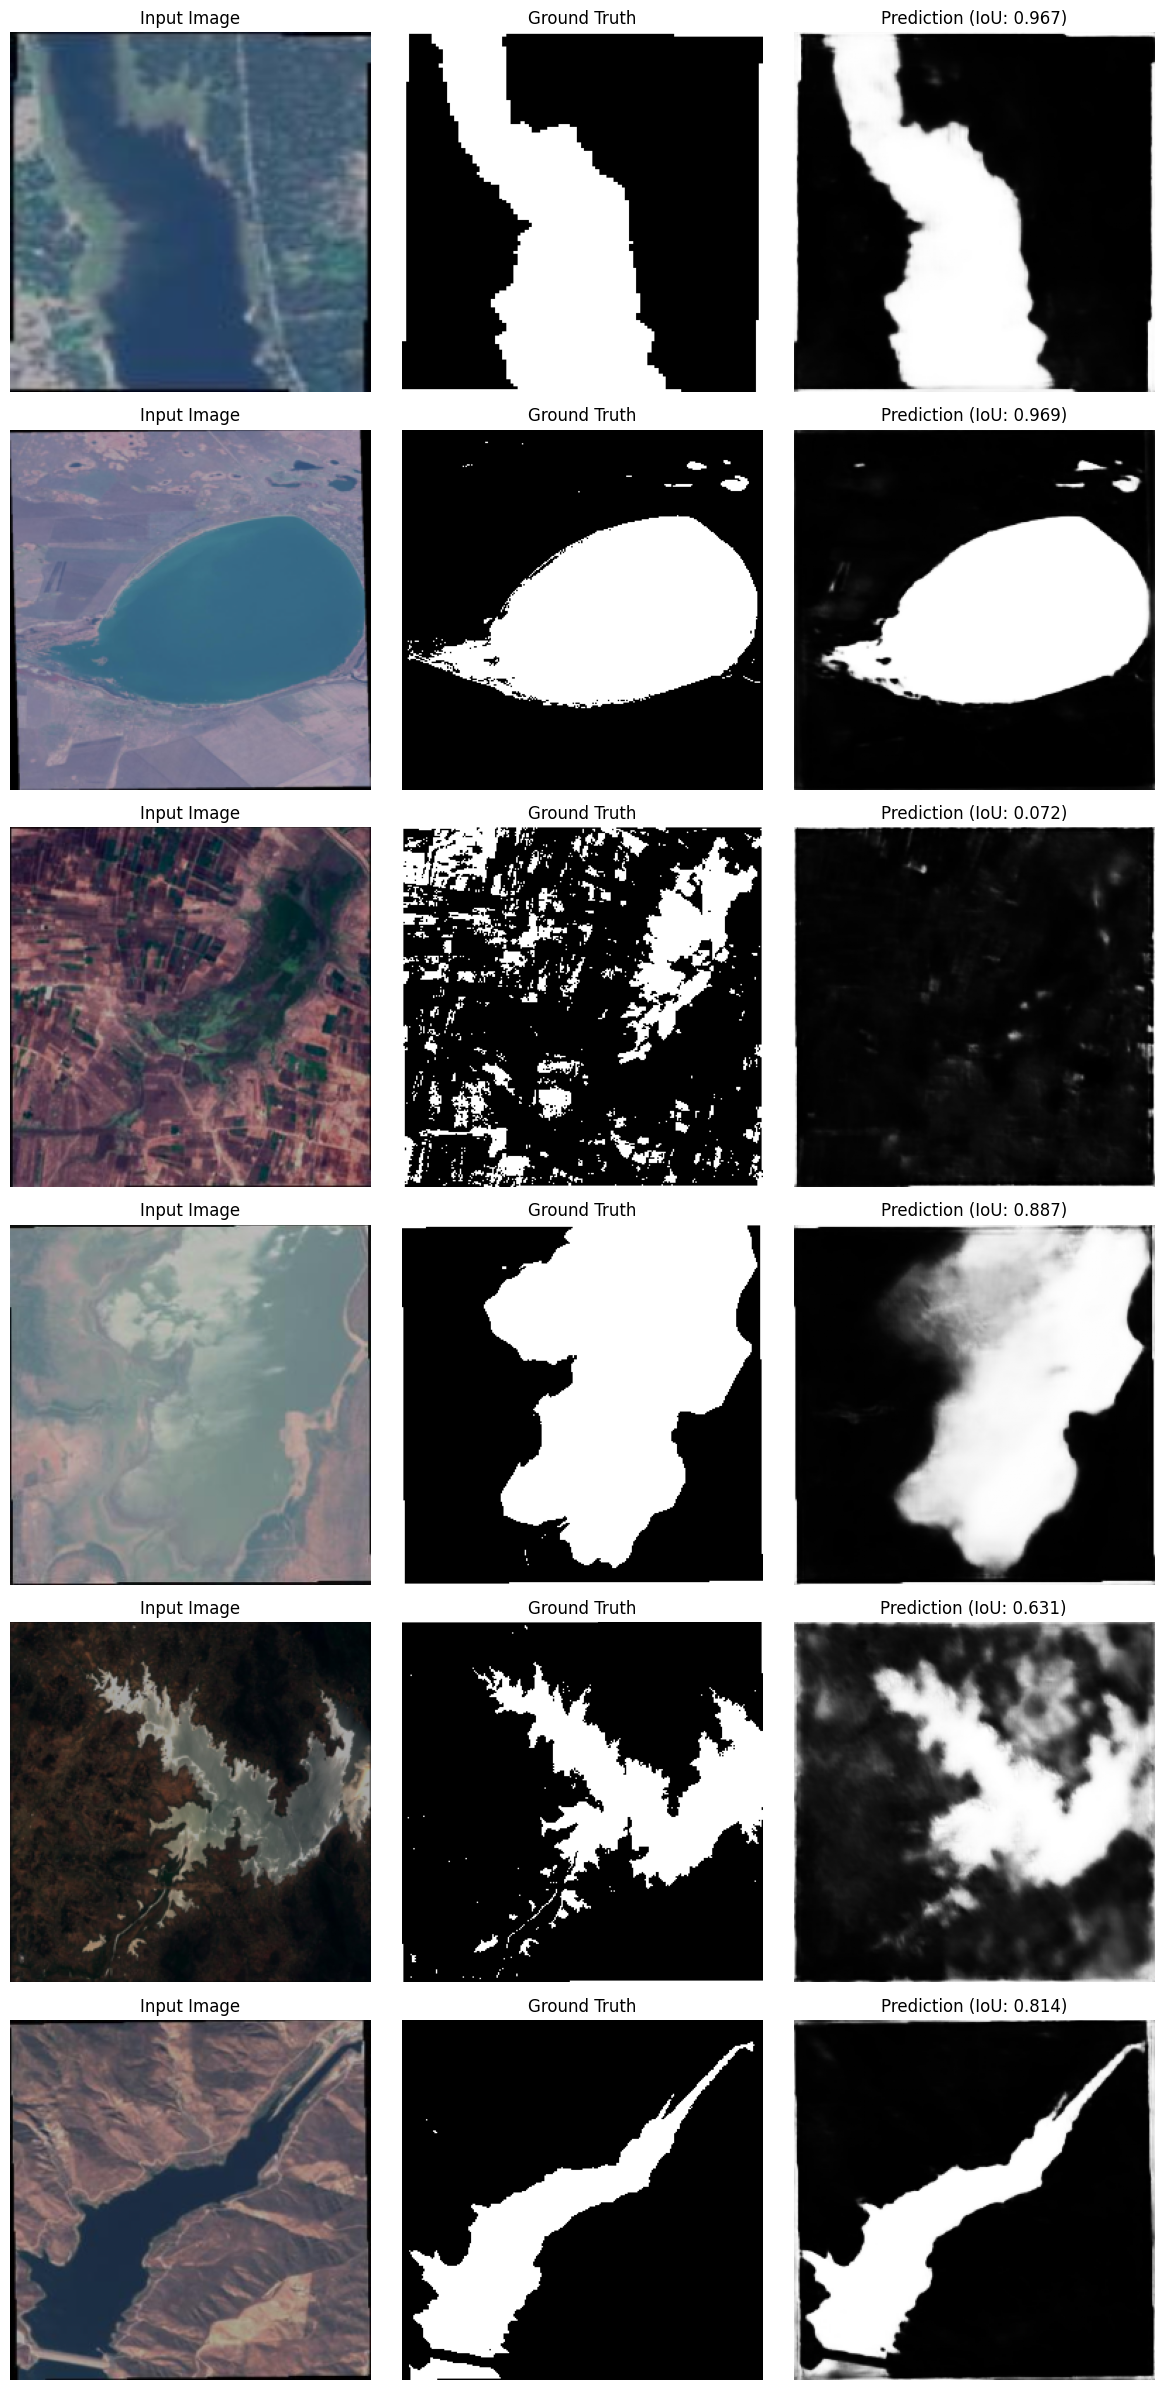

Segmentation results saved!


In [ ]:
# Get 6 random test samples
test_samples = []
test_indices = random.sample(range(len(test_ds)), 6)

model.eval()
with torch.no_grad():
    for idx in test_indices:
        image, mask = test_ds[idx]
        image_input = image.unsqueeze(0).to(device)
        output = model(image_input)
        pred = torch.sigmoid(output).squeeze().cpu().numpy()

        # Denormalize image for display
        img_disp = (image * STD + MEAN).permute(1, 2, 0).clamp(0, 1).numpy()
        mask_disp = mask.squeeze().numpy()

        # Calculate IoU for this sample
        pred_binary = (pred > 0.5).astype(np.float32)
        intersection = (pred_binary * mask_disp).sum()
        union = pred_binary.sum() + mask_disp.sum() - intersection
        sample_iou = intersection / (union + 1e-6)

        test_samples.append((img_disp, mask_disp, pred, sample_iou))

# Plot 6x3 grid
fig, axes = plt.subplots(6, 3, figsize=(12, 24))

for i, (img, mask, pred, iou) in enumerate(test_samples):
    axes[i, 0].imshow(img)
    axes[i, 0].set_title("Input Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask, cmap="gray", vmin=0, vmax=1)
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(pred, cmap="gray", vmin=0, vmax=1)
    axes[i, 2].set_title(f"Prediction (IoU: {iou:.3f})")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'segmentation_results.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Segmentation results saved!")



In [ ]:
print("\\n" + "="*60)
print("WATER BODY SEGMENTATION - SUMMARY")
print("="*60)
print(f"Dataset: 2841 image-mask pairs")
print(f"Train/Val/Test Split: {len(train_ds)}/{len(val_ds)}/{len(test_ds)}")
print(f"Model: U-Net with ResNet34 encoder")
print(f"Loss: BCEDiceLoss (0.5 * BCE + 0.5 * Dice)")
print(f"\\nBest Validation Loss: {best_val_loss:.4f}")
print(f"Test IoU: {test_iou:.4f}")
print(f"Test Dice: {test_dice:.4f}")
print(f"\\nResults saved to: {SAVE_DIR}")
print("="*60)



\n============================================================
WATER BODY SEGMENTATION - SUMMARY
Dataset: 2841 image-mask pairs
Train/Val/Test Split: 1988/426/427
Model: U-Net with ResNet34 encoder
Loss: BCEDiceLoss (0.5 * BCE + 0.5 * Dice)
\nBest Validation Loss: 0.1681
Test IoU: 0.8012
Test Dice: 0.8690
\nResults saved to: /content/drive/MyDrive/water_segmentation
